This file is dedicated to testing ways to deal with the NaN instances in the features, for the logistic regression. 
Can possibly be usefull fo other methods too.

TARGET_B                    0
RECENT_AVG_GIFT_AMT         0
LAST_GIFT_AMT               0
LIFETIME_AVG_GIFT_AMT       0
RECENT_AVG_CARD_GIFT_AMT    0
LIFETIME_MAX_GIFT_AMT       0
NUMBER_PROM_12              0
MONTHS_SINCE_LAST_GIFT      0
MONTHS_SINCE_FIRST_GIFT     0
LIFETIME_GIFT_COUNT         0
PER_CAPITA_INCOME           0
MEDIAN_HOUSEHOLD_INCOME     0
RECENT_RESPONSE_PROP        0
RECENT_RESPONSE_COUNT       0
WEALTH_RATING               0
URBANICITY                  0
SES                         0
DONOR_GENDER                0
RECENCY_STATUS_96NK         0
WEALTH_RATING_unknown       0
dtype: int64
Train set score (Accuracy) = 0.5872393144744993
Test set score (Accuracy)  = 0.5812512905224034



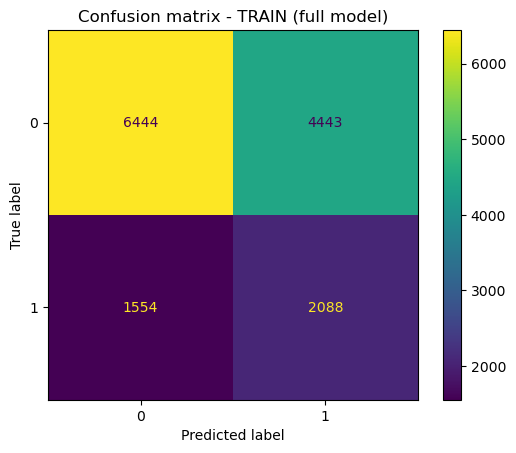

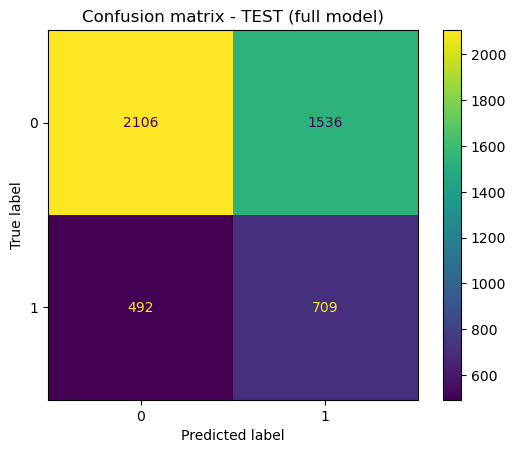


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.81      0.59      0.68     10887
           1       0.32      0.57      0.41      3642

    accuracy                           0.59     14529
   macro avg       0.56      0.58      0.55     14529
weighted avg       0.68      0.59      0.61     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.58      0.68      3642
           1       0.32      0.59      0.41      1201

    accuracy                           0.58      4843
   macro avg       0.56      0.58      0.54      4843
weighted avg       0.69      0.58      0.61      4843



In [ ]:
### Logistic Regression with numerical and categorical numerical features. Adapted experiments with the c value, penalty and solver.
# I used the automatic balancing of the logaritmic regression.
# First try at adding the WEALTH_RATING feature. 
# I substituted the unknowns by the median and added a new dummy column with a WEALTH_RATING_unknown, to identify such cases.
# Results: only a very slight improvement, almost imperceptible. 
# Still it might be better to keep this feature, since the model is responding positively to an increase in the number of features.
# Yet, it is advisable to try with and without the WEALTH_RATING feature, in future experiments. 


import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT", "WEALTH_RATING"
]


cat_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

C = 1
penalty = 'l2' # or l1
solver = 'liblinear'


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}



# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

df_B['WEALTH_RATING_unknown'] = df_B['WEALTH_RATING'].isna().astype(int)

# 2) Fill missing WEALTH_RATING with the median
wr_median = df_B['WEALTH_RATING'].median()
df_B['WEALTH_RATING'] = df_B['WEALTH_RATING'].fillna(wr_median)

# check missing values
print(df_B.isna().sum())

# 3) One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

# 4) Final X and y
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']




X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=100000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_full.score(X_B_train, y_B_train))
print("Test set score (Accuracy)  =", logreg_full.score(X_B_test, y_B_test))

print()


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))


